# Lab 03 — Supervised learning II: model families

*Neighbours, naive Bayes, trees, ensembles, and support vector machines on one workflow*

**Goal.** Hold the validation workflow from Lab 2 fixed and change one model family at a time: see the boundary each family draws, watch a tree overfit as it grows, check whether ensembles earn their cost, and tune an SVM's two dials.

**Data.** `all_datasets/breast_cancer_dataset.csv`, `all_datasets/titanic_dataset.csv`, `all_datasets/ames_housing_dataset.csv`, `all_datasets/red_wine_quality_dataset.csv`

**Reading.** Chapters 11–14 (Nearest Neighbors and Naive Bayes; Decision Trees; Ensemble Methods; Support Vector Machines)

**Run.** Open a terminal in the course folder, run `cd all_experiments` and `jupyter lab`, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab03/` — k-selection table, tree rules, fold scores, grid-search table, metrics; `models/breast_cancer_svm.joblib`

**How much is scaffolded?** Fully worked. Every part reuses the same split-fit-validate pattern; only the estimator changes.

**Workflow**

1. Part A — KNN versus Gaussian naive Bayes
2. Part B — One readable decision tree, and what happens as it grows
3. Part C — Random forest versus gradient boosting
4. Part D — Support vector machines: two dials and a kernel
5. Try it yourself, with one solution

## Setup

Imports and paths. Notebooks run from `all_experiments/`, so the course folder is one level up; figures and tables go to `results/lab03/`.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.model_selection import (
    GridSearchCV, KFold, StratifiedKFold, cross_val_score, train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "all_datasets"
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)

RESULTS = PROJECT_ROOT / "results" / "lab03"
RESULTS.mkdir(parents=True, exist_ok=True)
print("course folder:", PROJECT_ROOT.name)

course folder: MACHINE LEARNING


## Part A — KNN versus Gaussian naive Bayes

Two classifiers built on very different ideas. KNN looks at the $k$ nearest training tumours (in standardized distance) and takes a vote. Gaussian naive Bayes assumes each feature is bell-shaped within each class and multiplies per-feature probabilities together.

In [2]:
cancer = pd.read_csv(DATA / "breast_cancer_dataset.csv")

X_c = cancer.drop(columns=["id", "diagnosis", "Unnamed: 32"], errors="ignore")
y_c = (cancer["diagnosis"] == "M").astype(int)

Xc_train, Xc_valid, yc_train, yc_valid = train_test_split(
    X_c, y_c, test_size=0.25, random_state=42, stratify=y_c
)

$k$ is a hyperparameter, so it is chosen by cross-validation inside the training partition. Small $k$ follows every local quirk (low bias, high variance); large $k$ smooths everything (high bias, low variance).

k= 1  cross-validated ROC AUC = 0.946
k= 3  cross-validated ROC AUC = 0.984
k= 5  cross-validated ROC AUC = 0.985
k= 7  cross-validated ROC AUC = 0.987


k=11  cross-validated ROC AUC = 0.988
k=21  cross-validated ROC AUC = 0.988
selected k: 11


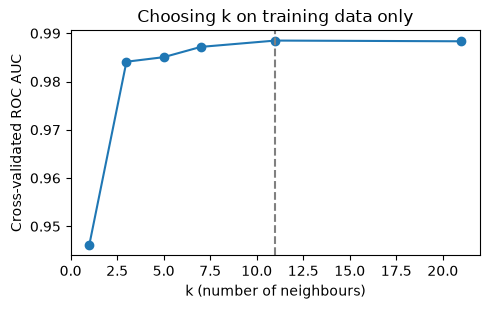

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_values = [1, 3, 5, 7, 11, 21]
cv_scores = {}

for k in k_values:
    candidate = Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k, weights="distance")),
    ])
    scores = cross_val_score(candidate, Xc_train, yc_train, cv=cv, scoring="roc_auc")
    cv_scores[k] = scores.mean()
    print(f"k={k:2d}  cross-validated ROC AUC = {scores.mean():.3f}")

best_k = max(cv_scores, key=cv_scores.get)
print("selected k:", best_k)

plt.figure(figsize=(5, 3.2))
plt.plot(k_values, [cv_scores[k] for k in k_values], marker="o")
plt.axvline(best_k, linestyle="--", color="grey")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Cross-validated ROC AUC")
plt.title("Choosing k on training data only")
plt.tight_layout()
plt.savefig(RESULTS / "choosing_k_on_training_data_only.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** The curve rises steeply from $k=1$ and then flattens. Anything from 7 to 21 is fine; $k=1$ is clearly worse because a single neighbour is easily fooled by one unusual tumour.

With $k$ locked, both models are compared on the validation split.

In [4]:
models = {
    "KNN": Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=best_k, weights="distance")),
    ]),
    "GaussianNB": Pipeline([
        ("scale", StandardScaler()),
        ("model", GaussianNB()),
    ]),
}

for name, model in models.items():
    model.fit(Xc_train, yc_train)
    pred = model.predict(Xc_valid)
    prob_c = model.predict_proba(Xc_valid)[:, 1]
    print(f"{name:10s} accuracy={accuracy_score(yc_valid, pred):.3f} "
          f"roc_auc={roc_auc_score(yc_valid, prob_c):.3f}")

KNN        accuracy=0.958 roc_auc=0.986
GaussianNB accuracy=0.944 roc_auc=0.992


Scores say the two models are close. Their decision boundaries say they think differently. Refitting each on just two features (tumour radius and texture) makes the boundary something you can draw, with logistic regression alongside for comparison.

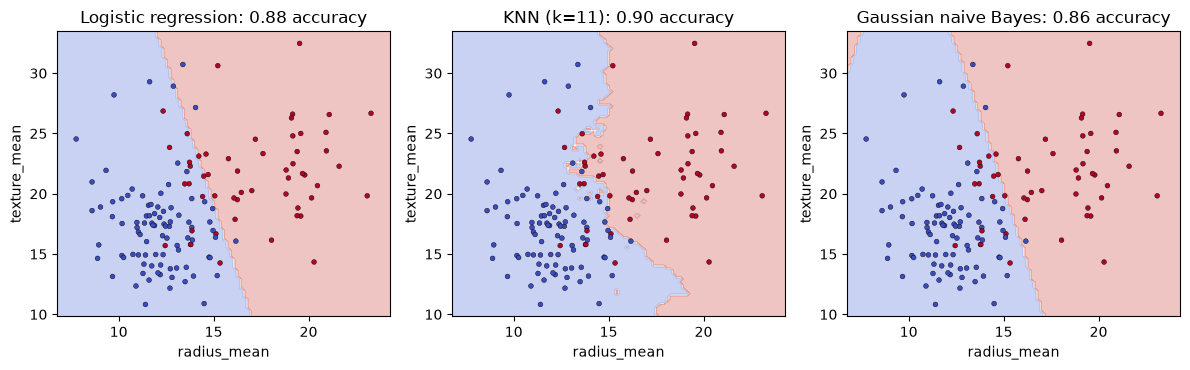

In [5]:
two = ["radius_mean", "texture_mean"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (name, estimator) in zip(axes, [
    ("Logistic regression", LogisticRegression(max_iter=2000)),
    (f"KNN (k={best_k})", KNeighborsClassifier(n_neighbors=best_k, weights="distance")),
    ("Gaussian naive Bayes", GaussianNB()),
]):
    small = Pipeline([("scale", StandardScaler()), ("model", estimator)])
    small.fit(Xc_train[two], yc_train)
    DecisionBoundaryDisplay.from_estimator(small, Xc_valid[two], ax=ax, alpha=0.3,
                                           response_method="predict", cmap="coolwarm")
    ax.scatter(Xc_valid[two[0]], Xc_valid[two[1]], c=yc_valid, cmap="coolwarm",
               s=12, edgecolor="k", linewidth=0.3)
    ax.set_title(f"{name}: {accuracy_score(yc_valid, small.predict(Xc_valid[two])):.2f} accuracy")
    ax.set_xlabel("radius_mean")
    ax.set_ylabel("texture_mean")
plt.tight_layout()
plt.savefig(RESULTS / f"{name}_{accuracy_score(yc_valid, small.predict(Xc_valid[two])):.2f}_accuracy.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Logistic regression draws one straight line. Naive Bayes draws a smooth curve, because it models each class as a bell. KNN draws a ragged boundary with small islands around individual tumours: that is the distance-based vote made visible, and it is why $k$ has to be chosen with care.

**What the output shows.** Cross-validated ROC AUC climbs from 0.946 at `k=1` to 0.988 at `k=11` and then flattens. With `k=11` locked, KNN scores accuracy 0.958 / ROC AUC 0.986 and naive Bayes 0.944 / 0.992. The boundary plot shows why they differ despite similar scores: a straight line, a smooth curve, and a ragged vote with islands.

## Part B — One readable decision tree, and what happens as it grows

Trees ask one yes/no question at a time and send each passenger left or right until a leaf gives the prediction. They split on the *order* of values, so numbers do not need scaling; the numeric branch of the preprocessor only fills gaps.

In [6]:
titanic = pd.read_csv(DATA / "titanic_dataset.csv")

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
t_num = ["Age", "SibSp", "Parch", "Fare"]
t_cat = ["Pclass", "Sex", "Embarked"]
X_t = titanic[features]
y_t = titanic["Survived"]

tree_preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), t_num),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), t_cat),
])

Xt_train, Xt_valid, yt_train, yt_valid = train_test_split(
    X_t, y_t, test_size=0.25, random_state=42, stratify=y_t
)

tree = Pipeline([
    ("preprocess", tree_preprocess),
    ("tree", DecisionTreeClassifier(max_depth=4, min_samples_leaf=12, random_state=42)),
])
tree.fit(Xt_train, yt_train)
print("training accuracy:", round(accuracy_score(yt_train, tree.predict(Xt_train)), 3))
print("validation accuracy:", round(accuracy_score(yt_valid, tree.predict(Xt_valid)), 3))

training accuracy: 0.843
validation accuracy: 0.767


The fitted tree can be printed as text and drawn as a picture. Each box shows the question, how many passengers reached it, and how they split between the two classes.

|--- cat__Sex_female <= 0.50
|   |--- num__Age <= 3.50
|   |   |--- class: 1
|   |--- num__Age >  3.50
|   |   |--- cat__Pclass_1 <= 0.50
|   |   |   |--- num__Fare <= 48.09
|   |   |   |   |--- class: 0
|   |   |   |--- num__Fare >  48.09
|   |   |   |   |--- class: 0
|   |   |--- cat__Pclass_1 >  0.50
|   |   |   |--- num__Age <= 53.00
|   |   |   |   |--- class: 0
|   |   |   |--- num__Age >  53.00
|   |   |   |   |--- class: 0
|--- cat__Sex_female >  0.50
|   |--- cat__Pclass_3 <= 0.50
|   |   |--- num__Fare <= 28.86
|   |   |   |--- num__Age <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- num__Age >  37.00
|   |   |   |   |--- class: 1
|   |   |--- num__Fare >  28.86
|   |   |   |--- num__Parch <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- num__Parch >  1.50
|   |   |   |   |--- class: 1
|   |--- cat__Pclass_3 >  0.50
|   |   |--- num__Fare <= 7.89
|   |   |   |--- cat__Embarked_S <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- cat__Embarked_S >  0.50
|   |

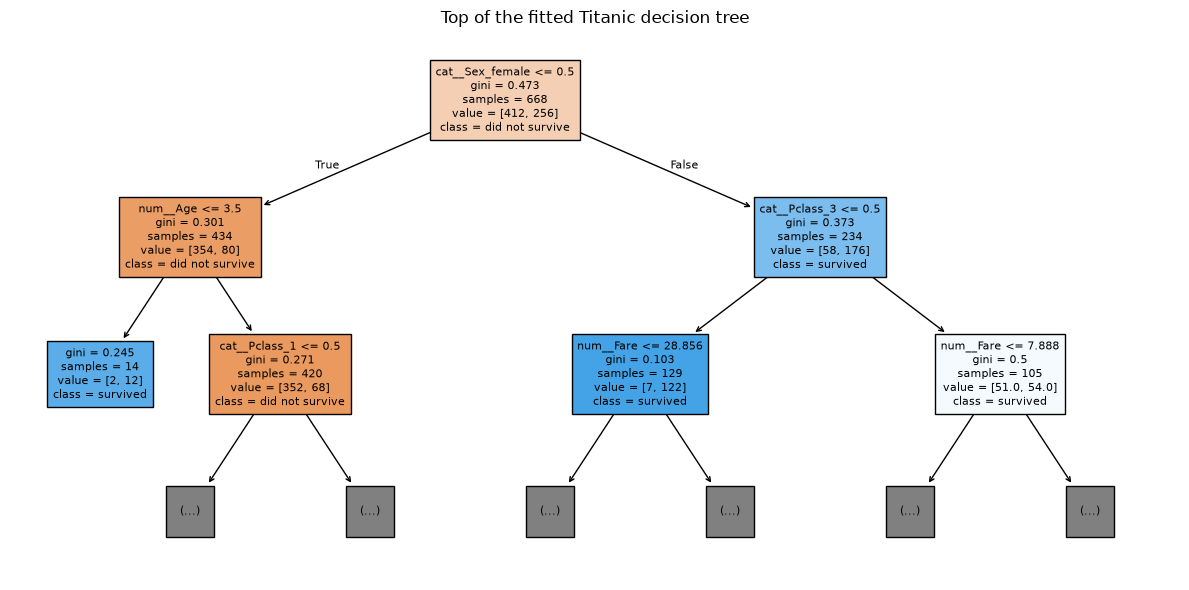

In [7]:
feature_names = list(tree.named_steps["preprocess"].get_feature_names_out())
print(export_text(tree.named_steps["tree"], feature_names=feature_names, max_depth=3))

plt.figure(figsize=(12, 6))
plot_tree(tree.named_steps["tree"], feature_names=feature_names,
          class_names=["did not survive", "survived"], max_depth=2, filled=True, fontsize=8)
plt.title("Top of the fitted Titanic decision tree")
plt.tight_layout()
plt.savefig(RESULTS / "top_of_the_fitted_titanic_decision_tree.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** The root question is sex. Among men the next question is age (very young boys survive); among women it is class. That is the Lab 1 group table rediscovered by the algorithm, as a set of if–then rules you could apply by hand.

What happens as the tree is allowed to grow? Fit one tree per depth and score it on both partitions. This is the bias–variance trade-off from the notes, drawn from real data.

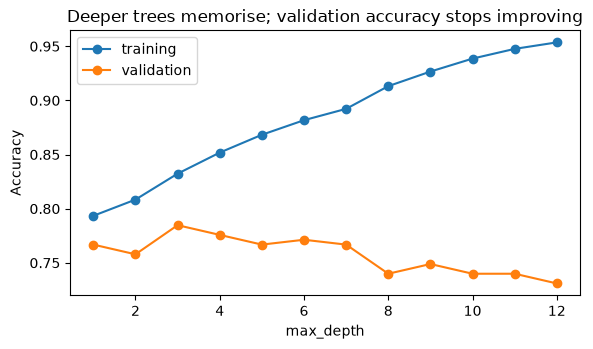

In [8]:
depths = list(range(1, 13))
train_acc, valid_acc = [], []
for depth in depths:
    t = Pipeline([
        ("preprocess", tree_preprocess),
        ("tree", DecisionTreeClassifier(max_depth=depth, random_state=42)),
    ]).fit(Xt_train, yt_train)
    train_acc.append(accuracy_score(yt_train, t.predict(Xt_train)))
    valid_acc.append(accuracy_score(yt_valid, t.predict(Xt_valid)))

plt.figure(figsize=(6, 3.6))
plt.plot(depths, train_acc, marker="o", label="training")
plt.plot(depths, valid_acc, marker="o", label="validation")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Deeper trees memorise; validation accuracy stops improving")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "deeper_trees_memorise_validation_accuracy_stops_improving.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Training accuracy climbs towards 1.0 as depth grows, because a deep enough tree can give every passenger a leaf of their own. Validation accuracy peaks early and then drifts down. The gap between the curves is variance, and depth is the dial that controls it.

**What the output shows.** Training accuracy 0.843, validation 0.767 for the depth-4 tree. The rules are readable: sex first, then age for men and class for women. The depth curve shows training accuracy heading to 1.0 while validation peaks around depth 3–5 and drifts down.

## Part C — Random forest versus gradient boosting

Ames Housing has 80 columns of mixed types describing houses, and a sale price that is strongly right-skewed, so $\log(1+\text{price})$ is modelled. A random forest averages many deep trees grown on different bootstrap samples; gradient boosting grows shallow trees one after another, each fitting what the previous ones got wrong. Both are scored on the same three folds. This cell takes about a minute.

random_forest      CV log-RMSE = 0.1382 +/- 0.0118


gradient_boosting  CV log-RMSE = 0.1273 +/- 0.0141


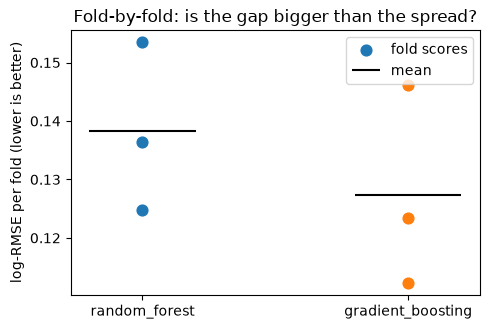

In [9]:
ames = pd.read_csv(DATA / "ames_housing_dataset.csv")
X_a = ames.drop(columns=["SalePrice", "Order", "PID"], errors="ignore")   # identifiers out
y_a = np.log1p(ames["SalePrice"])

ames_preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), X_a.select_dtypes(include="number").columns),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), X_a.select_dtypes(exclude="number").columns),
])
ensembles = {
    "random_forest": RandomForestRegressor(
        n_estimators=150, max_features=0.8, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=3, loss="huber", random_state=42
    ),
}

cv3 = KFold(n_splits=3, shuffle=True, random_state=42)
cv_rmse = {}
for name, estimator in ensembles.items():
    pipe = Pipeline([("preprocess", ames_preprocess), ("model", estimator)])
    neg_mse = cross_val_score(pipe, X_a, y_a, cv=cv3, scoring="neg_mean_squared_error")
    cv_rmse[name] = np.sqrt(-neg_mse)
    print(f"{name:18s} CV log-RMSE = {cv_rmse[name].mean():.4f} +/- {cv_rmse[name].std():.4f}")

plt.figure(figsize=(5, 3.4))
for i, (name, values) in enumerate(cv_rmse.items()):
    plt.scatter([i] * len(values), values, s=60, label="fold scores" if i == 0 else None)
    plt.hlines(values.mean(), i - 0.2, i + 0.2, color="black", label="mean" if i == 0 else None)
plt.xticks(range(len(cv_rmse)), list(cv_rmse))
plt.ylabel("log-RMSE per fold (lower is better)")
plt.title("Fold-by-fold: is the gap bigger than the spread?")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fold_by_fold_is_the_gap_bigger_than_the_spread.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Boosting is better on every fold, but its three dots overlap the forest's. The gain is real and modest, and it cost more tuning and more training time. Whether that trade is worth it is a judgement, not a number.

The same two ensembles on a small numeric table: eleven chemical measurements per wine and a quality score from 3 to 8. Permutation importance then shuffles one column at a time in the validation data and records how much the error gets worse, which tells you what the forest actually relies on.

random_forest      MAE = 0.432  RMSE = 0.565
gradient_boosting  MAE = 0.476  RMSE = 0.597


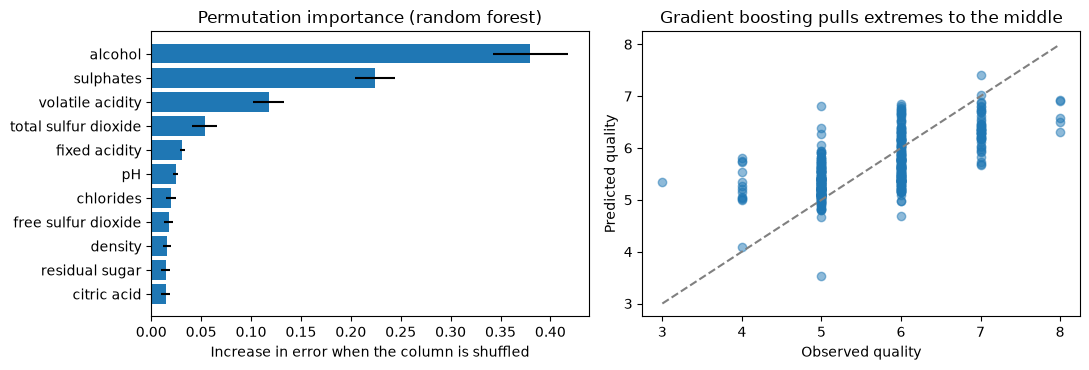

In [10]:
wine = pd.read_csv(DATA / "red_wine_quality_dataset.csv")
X_w = wine.drop(columns="quality")
y_w = wine["quality"]
Xw_train, Xw_valid, yw_train, yw_valid = train_test_split(X_w, y_w, test_size=0.25, random_state=42)

wine_models = {
    "random_forest": RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                           random_state=42, n_jobs=-1),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
}
wine_pred = {}
for name, model in wine_models.items():
    model.fit(Xw_train, yw_train)
    wine_pred[name] = model.predict(Xw_valid)
    print(f"{name:18s} MAE = {mean_absolute_error(yw_valid, wine_pred[name]):.3f}  "
          f"RMSE = {np.sqrt(mean_squared_error(yw_valid, wine_pred[name])):.3f}")

importance = permutation_importance(
    wine_models["random_forest"], Xw_valid, yw_valid, n_repeats=10, random_state=42, n_jobs=-1
)
ranked = pd.Series(importance.importances_mean, index=X_w.columns).sort_values()
spread = importance.importances_std[np.argsort(importance.importances_mean)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].barh(ranked.index, ranked.values, xerr=spread)
axes[0].set_xlabel("Increase in error when the column is shuffled")
axes[0].set_title("Permutation importance (random forest)")
axes[1].scatter(yw_valid, wine_pred["gradient_boosting"], alpha=0.5)
axes[1].plot([3, 8], [3, 8], linestyle="--", color="grey")
axes[1].set_xlabel("Observed quality")
axes[1].set_ylabel("Predicted quality")
axes[1].set_title("Gradient boosting pulls extremes to the middle")
plt.tight_layout()
plt.savefig(RESULTS / "gradient_boosting_pulls_extremes_to_the_middle.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Alcohol and sulphates dominate; several columns could be dropped without loss. On the right, wines rated 3 or 8 are predicted near 5 or 6: averaging methods pull rare extreme cases toward the crowd. Here the forest beats boosting, the reverse of the Ames result, so no family wins everywhere.

**What the output shows.** Ames log-RMSE: forest 0.138 ± 0.012, boosting 0.127 ± 0.014, roughly a 13% typical price error for boosting; it wins on every fold, but the dots overlap. Wine: forest MAE 0.43, boosting 0.48, the reverse result. Permutation importance puts alcohol and sulphates far ahead of the rest.

## Part D — Support vector machines: two dials and a kernel

An SVM looks for the boundary with the widest margin between the classes. It measures margins in feature units, so the scaler goes inside the pipeline and is refitted in every fold. `C` is how strictly training mistakes are punished (large $C$: narrow margin, follows the data closely). The kernel decides the *shape* of boundary allowed. For the RBF kernel, `gamma` sets how far each training point's influence reaches (large γ: very local, wiggly boundary).

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_c, y_c, test_size=0.25, random_state=42, stratify=y_c
)

svm_pipe = Pipeline([("scale", StandardScaler()), ("model", SVC())])
search = GridSearchCV(
    svm_pipe,
    param_grid={
        "model__kernel": ["linear", "rbf"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.01, 0.1],
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
)
search.fit(X_train, y_train)

score = search.decision_function(X_test)
pred = search.predict(X_test)
print("best parameters:", search.best_params_)
print("cross-validated ROC AUC:", round(search.best_score_, 3))
print("test accuracy:", round(accuracy_score(y_test, pred), 3))
print("test ROC AUC:", round(roc_auc_score(y_test, score), 3))

best parameters: {'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
cross-validated ROC AUC: 0.995
test accuracy: 0.979
test ROC AUC: 0.997


A heat map of the RBF results shows how the two dials interact; each cell is the cross-validated ROC AUC for one $(C,\gamma)$ pair. Beside it, the two kernels refitted on radius and texture show the shape of boundary each is allowed to draw.

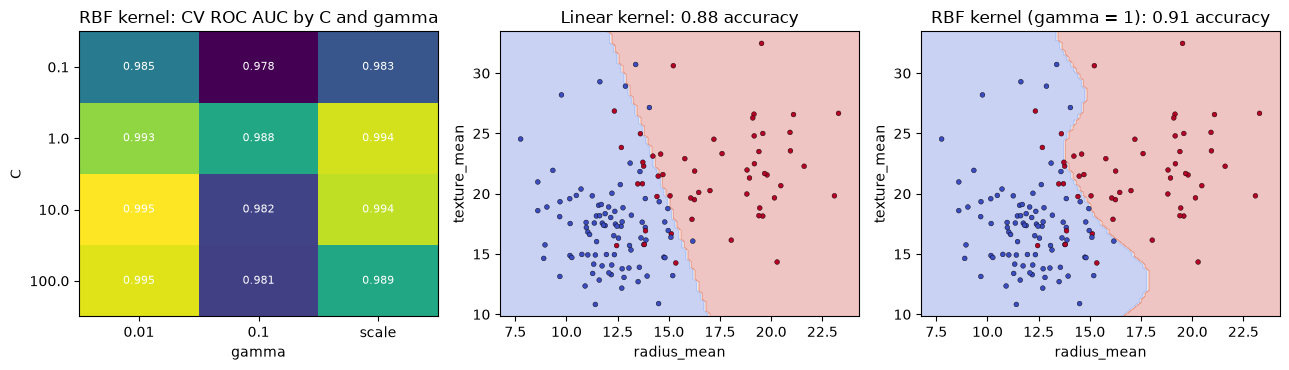

In [12]:
results = pd.DataFrame(search.cv_results_)
rbf = results[results["param_model__kernel"] == "rbf"].copy()
rbf["gamma"] = rbf["param_model__gamma"].astype(str)
grid = rbf.pivot(index="param_model__C", columns="gamma", values="mean_test_score")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
im = axes[0].imshow(grid.values, cmap="viridis", aspect="auto")
axes[0].set_xticks(range(len(grid.columns)), grid.columns)
axes[0].set_yticks(range(len(grid.index)), grid.index)
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("C")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        axes[0].text(j, i, f"{grid.values[i, j]:.3f}", ha="center", va="center",
                     color="white", fontsize=8)
axes[0].set_title("RBF kernel: CV ROC AUC by C and gamma")
for ax, (title, estimator) in zip(axes[1:], [
    ("Linear kernel", SVC(kernel="linear", C=1)),
    ("RBF kernel (gamma = 1)", SVC(kernel="rbf", C=1, gamma=1.0)),
]):
    small = Pipeline([("scale", StandardScaler()), ("model", estimator)]).fit(X_train[two], y_train)
    DecisionBoundaryDisplay.from_estimator(small, X_test[two], ax=ax, alpha=0.3,
                                           response_method="predict", cmap="coolwarm")
    ax.scatter(X_test[two[0]], X_test[two[1]], c=y_test, cmap="coolwarm",
               s=12, edgecolor="k", linewidth=0.3)
    ax.set_title(f"{title}: {accuracy_score(y_test, small.predict(X_test[two])):.2f} accuracy")
    ax.set_xlabel("radius_mean")
    ax.set_ylabel("texture_mean")
plt.tight_layout()
plt.savefig(RESULTS / f"{title}_{accuracy_score(y_test, small.predict(X_test[two])):.2f}_accuracy.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Most heat-map cells are within a hair of each other; only the large-γ, small-$C$ corner underfits. The linear kernel draws one straight line; the RBF kernel with a large γ bends around groups of points and carves out islands. On this data the extra flexibility buys little: once scaled, the classes are close to linearly separable.

The tuned model is saved and reloaded, and the reloaded copy is checked against the in-memory predictions. That check should be a habit before any model file is handed to someone else.

In [13]:
model_path = MODELS / "breast_cancer_svm.joblib"
joblib.dump(search.best_estimator_, model_path)
loaded = joblib.load(model_path)
same = np.array_equal(loaded.predict(X_test), pred)
print("file size (KB):", round(model_path.stat().st_size / 1024, 1))
print("reloaded model reproduces the test predictions:", same)

file size (KB): 16.5
reloaded model reproduces the test predictions: True


**What the output shows.** Best: RBF kernel, `C=10`, `gamma=0.01`; test accuracy 0.979, ROC AUC 0.997. The heat map shows most cells within a few thousandths of each other, so on this data the kernel and `C` hardly matter; the two-feature boundaries make the same point visually. The saved file reproduces every test prediction.

## Evidence

Write the numbers above to the results folder. These files are regenerated on every run; do not edit them by hand.

In [14]:
pd.Series(cv_scores, name="cv_roc_auc").rename_axis("k").round(4).to_csv(RESULTS / "knn_selection.csv")
(RESULTS / "titanic_tree_rules.txt").write_text(export_text(tree.named_steps["tree"], feature_names=feature_names, max_depth=3))
pd.DataFrame(cv_rmse).round(4).to_csv(RESULTS / "ames_fold_scores.csv", index=False)
pd.DataFrame(search.cv_results_)[["param_model__kernel", "param_model__C", "param_model__gamma",
                                  "mean_test_score", "std_test_score", "rank_test_score"]].sort_values(
    "rank_test_score").round(4).to_csv(RESULTS / "svm_grid_search.csv", index=False)
rows = [{"part": "A", "dataset": "breast_cancer", "model": name, "metric": "roc_auc",
         "validation": roc_auc_score(yc_valid, m.predict_proba(Xc_valid)[:, 1])} for name, m in models.items()]
rows.append({"part": "B", "dataset": "titanic", "model": "decision_tree(depth=4)", "metric": "accuracy",
             "validation": accuracy_score(yt_valid, tree.predict(Xt_valid))})
rows += [{"part": "C", "dataset": "red_wine_quality", "model": name, "metric": "mae",
          "validation": mean_absolute_error(yw_valid, p)} for name, p in wine_pred.items()]
rows.append({"part": "D", "dataset": "breast_cancer", "model": f"svc {search.best_params_}", "metric": "roc_auc",
             "validation": search.best_score_, "test": roc_auc_score(y_test, score)})
pd.DataFrame(rows).round(4).to_csv(RESULTS / "metrics.csv", index=False)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['Gaussian naive Bayes_0.86_accuracy.png', 'RBF kernel (gamma = 1)_0.91_accuracy.png', 'ames_fold_scores.csv', 'choosing_k_on_training_data_only.png', 'deeper_trees_memorise_validation_accuracy_stops_improving.png', 'fold_by_fold_is_the_gap_bigger_than_the_spread.png', 'gradient_boosting_pulls_extremes_to_the_middle.png', 'knn_selection.csv', 'metrics.csv', 'svm_grid_search.csv', 'titanic_tree_rules.txt', 'top_of_the_fitted_titanic_decision_tree.png']


## Try it yourself

Grow the Titanic tree with `max_depth=None` and `min_samples_leaf=1`, and compare training and validation accuracy with the depth-4 tree. Then refit the SVM search with only the linear kernel and compare its test ROC AUC with the RBF result.

Attempt it in the cell below before reading the solution.

In [15]:
# Your work here


### One solution

An unrestricted tree, then a linear-only SVM search.

In [16]:
deep = Pipeline([
    ("preprocess", tree_preprocess),
    ("tree", DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=42)),
]).fit(Xt_train, yt_train)
print("depth-4 tree:      training", round(accuracy_score(yt_train, tree.predict(Xt_train)), 3),
      " validation", round(accuracy_score(yt_valid, tree.predict(Xt_valid)), 3))
print("unrestricted tree: training", round(accuracy_score(yt_train, deep.predict(Xt_train)), 3),
      " validation", round(accuracy_score(yt_valid, deep.predict(Xt_valid)), 3),
      " depth", deep.named_steps["tree"].get_depth(), " leaves", deep.named_steps["tree"].get_n_leaves())

linear_search = GridSearchCV(
    svm_pipe, param_grid={"model__kernel": ["linear"], "model__C": [0.1, 1, 10, 100]},
    cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="roc_auc", n_jobs=-1,
).fit(X_train, y_train)
print("\nlinear SVM best C:", linear_search.best_params_["model__C"])
print("linear SVM test ROC AUC:", round(roc_auc_score(y_test, linear_search.decision_function(X_test)), 3))
print("RBF SVM test ROC AUC:   ", round(roc_auc_score(y_test, score), 3))
table = pd.DataFrame(linear_search.cv_results_)[["param_model__C", "mean_test_score", "std_test_score"]]
print(table.rename(columns={"param_model__C": "C", "mean_test_score": "mean", "std_test_score": "std"}).round(4).to_string(index=False))

depth-4 tree:      training 0.843  validation 0.767
unrestricted tree: training 0.978  validation 0.722  depth 21  leaves 146

linear SVM best C: 0.1
linear SVM test ROC AUC: 0.997
RBF SVM test ROC AUC:    0.997
    C   mean    std
  0.1 0.9932 0.0054
  1.0 0.9889 0.0095
 10.0 0.9838 0.0139
100.0 0.9816 0.0165


**What it shows.** The unrestricted tree grows to depth 21 with 146 leaves, many holding a single passenger, so it memorises the training set (0.978) and generalises *worse* than the four-question tree (0.722 against 0.767): the extra questions describe individuals rather than patterns. The linear SVM matches the RBF result on the test set (ROC AUC 0.997 for both), and its cross-validated score moves by about one point across a thousand-fold range of `C`, with the strongest regularization slightly ahead. On data that is nearly separable after scaling, the simpler kernel is a perfectly defensible choice.